# Operator resolved spectral functions

`h.get_dos(mode="KPM",operator=...)` projects the stochastic KPM trace onto a chosen *projector*
operator ($P^2=P$) before accumulating the moments, giving an operator-resolved spectral function
at the same cost as the total one. Below, a superconducting (Nambu) chain's total spectral function
is decomposed into its electron-sector projection, revealing the particle-hole-symmetric structure
of the Bogoliubov spectrum.

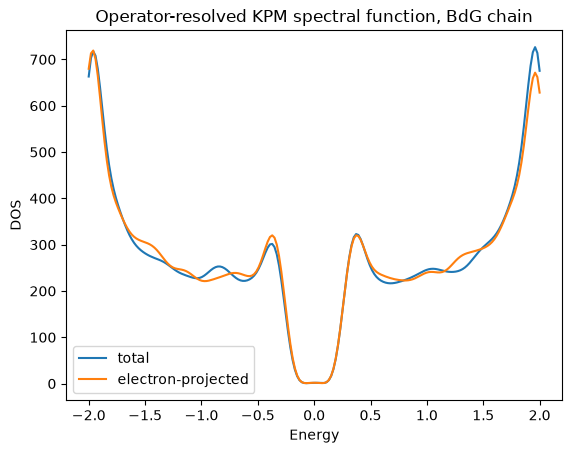

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
g = geometry.chain()
g = g.get_supercell(300)
g.dimensionality = 0
h = g.get_hamiltonian(has_spin=True,is_sparse=True)
h.add_swave(0.3)

energies = np.linspace(-2.,2.,200)
x,y_total = h.get_dos(mode="KPM",energies=energies,delta=5e-2,ntries=10)
x,y_electron = h.get_dos(mode="KPM",energies=energies,delta=5e-2,ntries=10,operator="electron")

plt.plot(x,y_total,label="total")
plt.plot(x,y_electron,label="electron-projected")
plt.xlabel("Energy") ; plt.ylabel("DOS")
plt.legend()
plt.title("Operator-resolved KPM spectral function, BdG chain")
plt.show()